# 匯入函式庫與讀取測站資料

In [13]:
import csv
import datetime
import urllib.parse
import requests
from bs4 import BeautifulSoup 
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

files = open("./station.csv", "r", encoding="utf-8-sig")
data = files.readlines()
files.close()

# 選取測站並爬取資料

In [ ]:
print("請輸入測站站號或站名：")
station = input()
flag = 0

print("")
stationList = []
for i in data:
    list = i.strip().split(",")
    #print(list[0], list[1], station)
    
    if station in str(list[0]) or station in str(list[1]):
        stationList = [list[0], list[1], list[2], urllib.parse.quote(urllib.parse.quote(list[1]))]

if len(stationList) != 0:
    tonow = datetime.datetime.now()
    today = [int(tonow.year), int(tonow.month), int(tonow.day)]
    print("選取測站：" + stationList[1])

    output = [["日期", "溫度", "降水量"]]
    for i in range(today[0] - 11, today[0] + 1):
        print("----", i, "----")
        for j in range(1, 13):
            if i == today[0] and j == today[1]:
                break
            if i == today[0] - 11 and j < today[1]:
                continue
            url = "https://e-service.cwb.gov.tw/HistoryDataQuery/MonthDataController.do?command=viewMain&station=" + stationList[0] + "&stname=" + stationList[3]+ "&datepicker=" + str(i) + "-" + str(j).zfill(2) + "&altitude=" + stationList[2] + "m#"
            page = requests.get(url)
            soup = BeautifulSoup(page.text,"html.parser")
            sel = soup.select("div.CSSTableGenerator td")
            for k in range(0, len(sel), 35):
                date = str(i) + "-" + str(j).zfill(2) + "-" + str(sel[k].text)
                print(date, sel[k + 7].text.rstrip(), sel[k + 21].text.rstrip())
                output.append([date, sel[k + 7].text.rstrip(), sel[k + 21].text.rstrip()])
                
else:
    print("無法讀取，請確認輸入是否有誤")


# 產製氣候圖

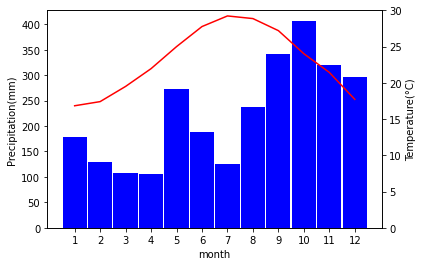

In [16]:
dayNumberT = [0] * 12
dayNumberP = [0] * 12
daySumT = [0.0] * 12
daySumP = [0.0] * 12
dayArray = [31, 28.25, 31, 30, 31, 30, 31, 31, 30, 31, 30, 31]

for line in output:
    mydate = line[0].strip().split("-")
    
    if "." in line[1] and "..." not in line[1]:
        daySumT[int(mydate[1])-1] += float(line[1])
        dayNumberT[int(mydate[1])-1] += 1
        
    if "." in line[2] and "..." not in line[2]:
        daySumP[int(mydate[1])-1] += float(line[2])
        dayNumberP[int(mydate[1])-1] += 1
        
    if "T" in line[2] or "&" in line[2] :
        dayNumberP[int(mydate[1])-1] += 1
        
for i in range(0, len(daySumT)):
    if dayNumberT[i] != 0:
        daySumT[i] /= dayNumberT[i]
    daySumP[i] = daySumP[i] / dayNumberP[i] * dayArray[i]

    
#出圖
fig, ax1 = plt.subplots()
plt.xlabel('month')
ax2 = ax1.twinx()

ax1.set_ylabel('Precipitation(mm)', color='black')
ax1.bar(["1", "2", "3", "4", "5", "6", "7", "8", "9", "10", "11", "12"], 
        daySumP,
        width=0.95, 
        bottom=None,
        color='blue',
        align='center')
ax1.tick_params(axis='y', labelcolor='black')

ax2.set_ylabel('Temperature(°C)', color='black')
plt.ylim((0, (float(daySumT[6])+0.3)//5 * 5 + 5))
ax2.tick_params(axis='y', labelcolor='black')
if not (stationList[0][0] == "C" and stationList[0][1] == "1"):
    ax2.plot(daySumT, color='red')
    

plt.show()

# 輸出csv

In [17]:
with open("./create_data/" + stationList[1] + "氣候資料" + '.csv', 'w', newline='') as csvfile:
    writer = csv.writer(csvfile)
    writer.writerows(output)
    
with open("./create_data/" + stationList[1] + "逐月平均氣候資料" + '.csv', 'w', newline='') as csvfile:
    writer = csv.writer(csvfile)
    writer.writerow(["月份", "溫度", "降水量"])
    for i in range(1, 13):
        writer.writerow([i, daySumT[i-1], daySumP[i-1]])